In [1]:
import pandas as pd           # Для удобной работы с табличными данными
import numpy as np            # Для математических операций с массивами
import os                     # Для работы с путями и папками
import glob                   # Для поиска файлов по шаблону (все .csv)
import matplotlib.pyplot as plt # Для создания графиков
import seaborn as sns         # Для красивой визуализации данных

# Инструменты машинного обучения
from sklearn.preprocessing import StandardScaler # Для приведения данных к одному масштабу
from sklearn.cluster import KMeans               # Алгоритм кластеризации (обучение без учителя)
from sklearn.decomposition import PCA           # Метод главных компонент (для сжатия данных в 2D)

In [2]:
# Указываем путь к твоей папке с данными
DATASET_PATH = '/home/lolkek3310/python/Подготовка Гомель/боты/N-BaIoT'

# Устанавливаем лимит строк из каждого файла (например, 5000)
# Это нужно, чтобы алгоритм работал быстро и не съел всю оперативную память
SAMPLE_SIZE = 5000

In [3]:
def load_data_for_clustering(path, n_rows):
    all_files = glob.glob(os.path.join(path, "*.csv"))
    data_list = []
    
    for f in all_files:
        # Пропускаем файлы, которые не содержат статистику трафика
        if any(skip in f for skip in ['summary', 'info', 'features', 'LightGBM']):
            continue
            
        # Читаем CSV файл
        temp_df = pd.read_csv(f)
        
        # Берем случайную выборку строк
        temp_df = temp_df.sample(n=min(len(temp_df), n_rows), random_state=42)
        
        # Сохраняем реальный ответ (0 или 1) в отдельную колонку 'true_label'
        # Мы НЕ будем давать её алгоритму для обучения
        temp_df['true_label'] = 0 if 'benign' in f else 1
        
        data_list.append(temp_df)
        
    # Склеиваем всё в одну большую таблицу
    return pd.concat(data_list, ignore_index=True)

# Запускаем сборку
df_raw = load_data_for_clustering(DATASET_PATH, SAMPLE_SIZE)
print(f"Данные собраны. Всего записей: {df_raw.shape[0]}")

Данные собраны. Всего записей: 445000


In [4]:
# Создаем X — данные без правильных ответов
X_unlabeled = df_raw.drop('true_label', axis=1)

# Считаем корреляцию (насколько признаки похожи друг на друга)
corr = X_unlabeled.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Находим колонки, которые похожи на другие более чем на 98%
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]

# Удаляем эти колонки
X_cleaned = X_unlabeled.drop(to_drop, axis=1)
print(f"Удалено {len(to_drop)} похожих признаков. Осталось {X_cleaned.shape[1]} уникальных.")

Удалено 66 похожих признаков. Осталось 49 уникальных.


In [5]:
# Создаем объект масштабатора
scaler = StandardScaler()

# Превращаем данные в такие, где среднее = 0, а разброс = 1
# Теперь "размер пакета" и "задержка" будут одинаково важны для ИИ
X_scaled = scaler.fit_transform(X_cleaned)

In [6]:
# Задаем количество групп (3)
# 1 группа - норма, 2 и 3 - разные стадии работы ботнета
km = KMeans(n_clusters=3, random_state=42, n_init=10)

# Алгоритм анализирует данные и присваивает каждой строке номер кластера (0, 1 или 2)
clusters = km.fit_predict(X_scaled)

# Добавляем результаты кластеризации в нашу таблицу
X_cleaned['cluster'] = clusters

In [7]:
# Считаем средние показатели для каждого кластера
cluster_summary = X_cleaned.groupby('cluster').mean()

# Ботнет выдает себя огромным количеством пакетов (weight)
# Ищем признак 'weight' и смотрим, в каком кластере он зашкаливает
weight_features = [c for c in cluster_summary.columns if 'weight' in c]
avg_intensity = cluster_summary[weight_features].mean(axis=1)

# Находим ID кластера с максимальной интенсивностью трафика
botnet_id = avg_intensity.idxmax()

print("\n--- РЕЗУЛЬТАТ АЛГОРИТМИЧЕСКОГО АНАЛИЗА ---")
for i in range(3):
    verdict = "ОПАСНОСТЬ (БОТНЕТ)" if i == botnet_id else "БЕЗОПАСНО (НОРМА)"
    print(f"Кластер №{i}: {verdict} | Средняя активность: {avg_intensity[i]:.2f}")


--- РЕЗУЛЬТАТ АЛГОРИТМИЧЕСКОГО АНАЛИЗА ---
Кластер №0: БЕЗОПАСНО (НОРМА) | Средняя активность: 2545.46
Кластер №1: БЕЗОПАСНО (НОРМА) | Средняя активность: 141.52
Кластер №2: ОПАСНОСТЬ (БОТНЕТ) | Средняя активность: 6478.73


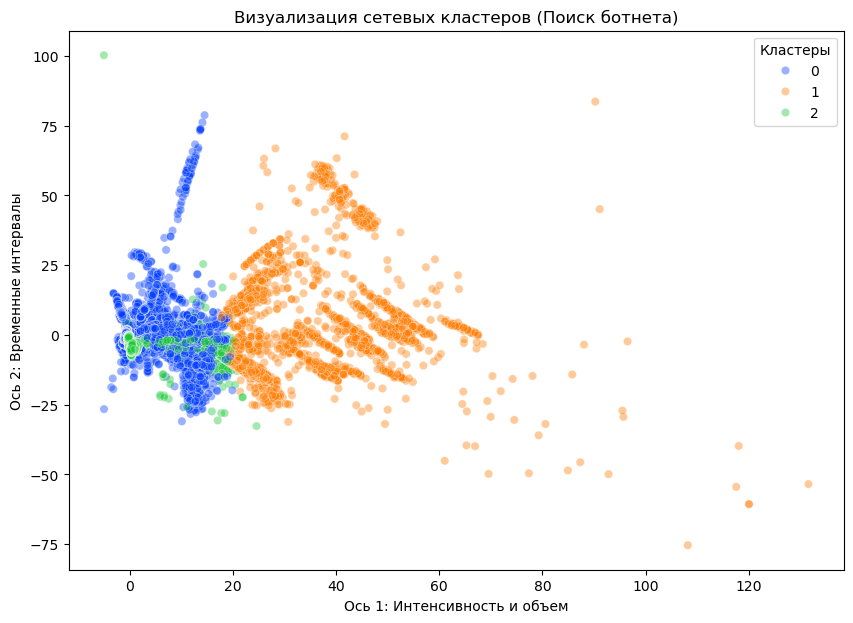

In [8]:
# Сжимаем данные до 2-х главных компонент
pca = PCA(n_components=2)
X_visual = pca.fit_transform(X_scaled)

# Рисуем график
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_visual[:, 0], y=X_visual[:, 1], hue=clusters, palette='bright', alpha=0.4)
plt.title('Визуализация сетевых кластеров (Поиск ботнета)')
plt.xlabel('Ось 1: Интенсивность и объем')
plt.ylabel('Ось 2: Временные интервалы')
plt.legend(title='Кластеры')
plt.show()

In [9]:
# Создаем таблицу сравнения: что нашел ИИ против того, что было в файлах на самом деле
validation = pd.DataFrame({'ИИ_Кластер': clusters, 'Реальность': df_raw['true_label']})

# Строим кросс-таблицу
check_table = pd.crosstab(validation['ИИ_Кластер'], validation['Реальность'])

print("\n--- ПРОВЕРКА ТОЧНОСТИ ---")
print(check_table)
print("\nПояснение: Если в строке кластера-ботнета много '1' и мало '0', значит анализ поведения сработал!")


--- ПРОВЕРКА ТОЧНОСТИ ---
Реальность      0       1
ИИ_Кластер               
0           41716  295674
1            2610     218
2             674  104108

Пояснение: Если в строке кластера-ботнета много '1' и мало '0', значит анализ поведения сработал!
